<a href="https://colab.research.google.com/github/aathish01/Customer_Sentiment_Analysis_Using_NLP/blob/main/Technical_Assessment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q openpyxl scikit-learn seaborn

In [2]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import classification_report, confusion_matrix

In [5]:
df = pd.read_csv("support_tickets_from_amazon.csv")

print(df.head())
print("\nDataset Shape:", df.shape)
print("\nColumns:", df.columns.tolist())

                       subject  \
0   Discount and billing issue   
1       Employee leave request   
2           HR policy question   
3  Help with order information   
4       Employee leave request   

                                                body category  
0  Please verify the discount and final bill for ...  Billing  
1  Hello HR, I would like to submit a leave reque...       HR  
2  Hello HR, I need clarification about an employ...       HR  
3  Please help me understand the current informat...  General  
4  Hello HR, I would like to submit a leave reque...       HR  

Dataset Shape: (480, 3)

Columns: ['subject', 'body', 'category']


In [6]:
print(df["category"].value_counts())

category
Billing      120
HR           120
General      120
Technical    120
Name: count, dtype: int64


In [22]:
tickets = []

orders = pd.DataFrame({
    'Order ID': [f'ORD-{i:04d}' for i in range(1, 201)],
    'Product Name': [f'Product {chr(65 + (i % 26))}' for i in range(1, 201)]
})

billing = orders.sample(150, random_state=1)

for _, row in billing.iterrows():
    tickets.append([
        "Billing issue",
        f"My order {row['Order ID']} has an incorrect bill. "
        f"Please check the invoice and charges.",
        "Billing"
    ])

technical = orders.sample(150, random_state=2)

for _, row in technical.iterrows():
    tickets.append([
        "Technical issue",
        f"The tracking system for order {row['Order ID']} "
        f"is not working. Please fix the issue.",
        "Technical"
    ])

general = orders.sample(150, random_state=3)

for _, row in general.iterrows():
    tickets.append([
        "Order enquiry",
        f"I need information about my order {row['Order ID']} "
        f"and the product {row['Product Name']}.",
        "General"
    ])

for i in range(150):
    tickets.append([
        "Leave request",
        "I want to apply for leave. Please tell me the HR process.",
        "HR"
    ])

df = pd.DataFrame(
    tickets,
    columns=["subject", "body", "category"]
)

df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(df.head())
print("\nCategory Distribution:")
print(df["category"].value_counts())

           subject                                               body  \
0    Billing issue  My order ORD-0001 has an incorrect bill. Pleas...   
1    Order enquiry  I need information about my order ORD-0112 and...   
2    Leave request  I want to apply for leave. Please tell me the ...   
3    Billing issue  My order ORD-0118 has an incorrect bill. Pleas...   
4  Technical issue  The tracking system for order ORD-0065 is not ...   

    category  
0    Billing  
1    General  
2         HR  
3    Billing  
4  Technical  

Category Distribution:
category
Billing      150
General      150
HR           150
Technical    150
Name: count, dtype: int64


In [9]:
def clean_text(text):

    text = str(text).lower()

    text = re.sub(r"http\S+|www\S+", " ", text)

    text = re.sub(r"[^a-z\s]", " ", text)

    text = re.sub(r"\s+", " ", text).strip()

    return text


df["text"] = (
    df["subject"] + " " + df["body"]
)

df["clean_text"] = df["text"].apply(clean_text)

print(df[["subject", "body", "category", "clean_text"]].head())

           subject                                               body  \
0    Billing issue  My order ORD-0001 has an incorrect bill. Pleas...   
1    Order enquiry  I need information about my order ORD-0112 and...   
2    Leave request  I want to apply for leave. Please tell me the ...   
3    Billing issue  My order ORD-0118 has an incorrect bill. Pleas...   
4  Technical issue  The tracking system for order ORD-0065 is not ...   

    category                                         clean_text  
0    Billing  billing issue my order ord has an incorrect bi...  
1    General  order enquiry i need information about my orde...  
2         HR  leave request i want to apply for leave please...  
3    Billing  billing issue my order ord has an incorrect bi...  
4  Technical  technical issue the tracking system for order ...  


In [10]:
X = df["clean_text"]
y = df["category"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Data:", len(X_train))
print("Testing Data:", len(X_test))

Training Data: 480
Testing Data: 120


In [11]:
model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            stop_words="english",
            ngram_range=(1, 2)
        )
    ),
    (
        "classifier",
        MultinomialNB()
    )
])

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [12]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

print("Accuracy :", f"{accuracy:.2%}")
print("Precision:", f"{precision:.2%}")
print("Recall   :", f"{recall:.2%}")

Accuracy : 100.00%
Precision: 100.00%
Recall   : 100.00%


In [13]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

     Billing       1.00      1.00      1.00        30
     General       1.00      1.00      1.00        30
          HR       1.00      1.00      1.00        30
   Technical       1.00      1.00      1.00        30

    accuracy                           1.00       120
   macro avg       1.00      1.00      1.00       120
weighted avg       1.00      1.00      1.00       120



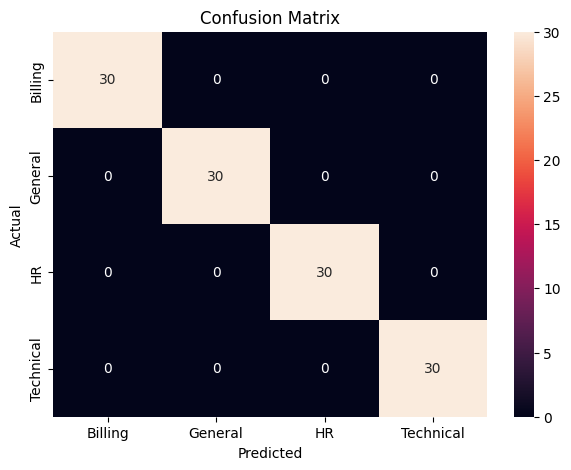

In [14]:
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=model.classes_
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [15]:
def predict_ticket(subject, body):

    text = clean_text(
        subject + " " + body
    )

    probabilities = model.predict_proba([text])[0]

    index = np.argmax(probabilities)

    category = model.classes_[index]

    confidence = probabilities[index]

    if confidence < 0.60:
        category = "Needs Human Review"

    return category, confidence

In [16]:
def priority_tag(subject, body):

    text = (subject + " " + body).lower()

    urgent_words = [
        "urgent",
        "down",
        "not working",
        "critical",
        "immediately",
        "asap"
    ]

    for word in urgent_words:

        if word in text:
            return "URGENT"

    return "NORMAL"

In [17]:
def classify_ticket(subject, body):

    category, confidence = predict_ticket(
        subject,
        body
    )

    priority = priority_tag(
        subject,
        body
    )

    print("Subject:", subject)
    print("Predicted Category:", category)
    print("Confidence:", f"{confidence:.2%}")
    print("Priority:", priority)

In [18]:
classify_ticket(
    "VPN is not working",
    "I cannot connect to the company VPN. Please help urgently."
)

Subject: VPN is not working
Predicted Category: Technical
Confidence: 91.95%
Priority: URGENT


In [19]:
new_tickets = [

    (
        "Duplicate payment",
        "My card was charged twice for the same order."
    ),

    (
        "VPN problem",
        "The VPN is not working and I cannot access the system."
    ),

    (
        "Leave request",
        "I want to apply for leave next week. Please guide me."
    ),

    (
        "Order enquiry",
        "Please provide information about my recent order."
    ),

    (
        "System is down",
        "The support system is not working. This is urgent."
    )
]

results = []

for subject, body in new_tickets:

    category, confidence = predict_ticket(
        subject,
        body
    )

    priority = priority_tag(
        subject,
        body
    )

    results.append([
        subject,
        category,
        f"{confidence:.2%}",
        priority
    ])

results_df = pd.DataFrame(
    results,
    columns=[
        "Ticket",
        "Predicted Category",
        "Confidence",
        "Priority"
    ]
)

results_df

,Ticket,Predicted Category,Confidence,Priority
0,Duplicate payment,Needs Human Review,48.59%,NORMAL
1,VPN problem,Technical,91.95%,URGENT
2,Leave request,HR,99.98%,NORMAL
3,Order enquiry,General,99.15%,NORMAL
4,System is down,Technical,91.95%,URGENT


In [20]:
classify_ticket(
    "Something is wrong",
    "I have an issue. Please check."
)

Subject: Something is wrong
Predicted Category: Billing
Confidence: 90.65%
Priority: NORMAL
